# 09 Design Descriptor and Virtual Design Analysis

This notebook extends the hydrovoltaic ML analysis by constructing an explicit, interpretable descriptor for hydrovoltaic performance.

The goal is not to maximize prediction accuracy, but to extract a compact design equation linking internal resistance, structure, ionic environment, and performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
# Adjust this path if needed
df = pd.read_csv(
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    encoding="utf-8-sig"
)

print(df.shape)
df.head()

(159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,...,ion_type,mechanism_simple,asym_env,asym_chem,asym_electrode,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,...,anion,streaming,1,0,0,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,...,anion,streaming,1,1,0,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0


## 09.2 Define target and descriptor features

In [3]:
TARGET = "log_estimated_power_density"

In [4]:
[c for c in df.columns if "power" in c.lower()]

['power_density_uW_cm2',
 'estimated_power_density_uW_cm2',
 'log_estimated_power_density']

In [5]:
TARGET = "log_estimated_power_density"
candidate_features = [
    "log_internal_resistance_Mohm",
    "structure_class",
    "ion_type",
    "mechanism_simple",
    "electrolyte_present",
    "inorganic_electrolyte"
]

available_features = [c for c in candidate_features if c in df.columns]

print("Available descriptor features:")
print(available_features)

Available descriptor features:
['log_internal_resistance_Mohm', 'structure_class', 'ion_type', 'mechanism_simple']


## 09.3 Build clean modeling table

In [6]:
df_desc = df[available_features + [TARGET]].copy()

df_desc = df_desc.replace([np.inf, -np.inf], np.nan)
df_desc = df_desc.dropna(subset=[TARGET])

print(df_desc.shape)
df_desc.head()

(159, 5)


,log_internal_resistance_Mohm,structure_class,ion_type,mechanism_simple,log_estimated_power_density
0,0.903090,porous,proton,streaming,-2.425853
1,1.535294,porous,anion,streaming,-2.698753
2,1.778151,porous,anion,streaming,-2.027982
3,NaN,porous,proton,streaming,-2.106738
4,NaN,porous,proton,streaming,-2.795609


In [7]:
# 缺失值先不要复杂处理，categorical 用 "unknown"，numeric 用 median。
numeric_features = [
    c for c in available_features
    if pd.api.types.is_numeric_dtype(df_desc[c])
]

categorical_features = [
    c for c in available_features
    if c not in numeric_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['log_internal_resistance_Mohm']
Categorical features: ['structure_class', 'ion_type', 'mechanism_simple']


In [8]:
for c in numeric_features:
    df_desc[c] = df_desc[c].fillna(df_desc[c].median())

for c in categorical_features:
    df_desc[c] = df_desc[c].fillna("unknown").astype(str)

X = df_desc[available_features]
y = df_desc[TARGET]

print(X.shape, y.shape)

(159, 4) (159,)


## 09.4 Elastic Net descriptor model
这个模型的意义：

用一个稀疏线性模型提取最小 design equation。

In [9]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

elastic_net_cv = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-4, 2, 80),
        cv=5,
        max_iter=20000,
        random_state=42
    ))
])

In [10]:
y_pred_train = elastic_net_cv.predict(X_train)
y_pred_test = elastic_net_cv.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)

test_mae = mean_absolute_error(y_test, y_pred_test)

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)

model = elastic_net_cv.named_steps["model"]

print("Best alpha:", model.alpha_)
print("Best l1_ratio:", model.l1_ratio_)

NameError: name 'X_train' is not defined

## 09.5 Cross-validation performance

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2 = cross_val_score(
    elastic_net_cv,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("CV R2 scores:", cv_r2)
print("Mean CV R2:", cv_r2.mean())
print("Std CV R2:", cv_r2.std())

c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


CV R2 scores: [0.30923523 0.28285927 0.29470286 0.29982824 0.06964203]
Mean CV R2: 0.2512535267699536
Std CV R2: 0.09120404225219486


## 09.6 Extract design equation coefficients

In [ ]:
# Get feature names after preprocessing
feature_names = elastic_net_cv.named_steps["preprocess"].get_feature_names_out()

coefs = elastic_net_cv.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(30)

,feature,coefficient,abs_coefficient
4,cat__structure_class_porous,-0.806655,0.806655
1,cat__structure_class_hydrogel,-0.772845,0.772845
5,cat__ion_type_other_cation,0.611370,0.611370
3,cat__structure_class_hydrogel + porous,-0.367438,0.367438
0,num__log_internal_resistance_Mohm,-0.361594,0.361594
7,cat__mechanism_simple_streaming,-0.341592,0.341592
2,cat__structure_class_hydrogel + film,0.243563,0.243563
6,cat__ion_type_proton,-0.065299,0.065299


In [ ]:
# 只保留非零项：
nonzero_coef_df = coef_df[coef_df["abs_coefficient"] > 1e-6].copy()

print("Number of non-zero terms:", len(nonzero_coef_df))
nonzero_coef_df

Number of non-zero terms: 8


,feature,coefficient,abs_coefficient
4,cat__structure_class_porous,-0.806655,0.806655
1,cat__structure_class_hydrogel,-0.772845,0.772845
5,cat__ion_type_other_cation,0.611370,0.611370
3,cat__structure_class_hydrogel + porous,-0.367438,0.367438
0,num__log_internal_resistance_Mohm,-0.361594,0.361594
7,cat__mechanism_simple_streaming,-0.341592,0.341592
2,cat__structure_class_hydrogel + film,0.243563,0.243563
6,cat__ion_type_proton,-0.065299,0.065299


In [ ]:
# 保存结果：
nonzero_coef_df.to_csv(
    "../results/09_elastic_net_descriptor_coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved descriptor coefficients.")

Saved descriptor coefficients.


## 09.7 Plot coefficient importance

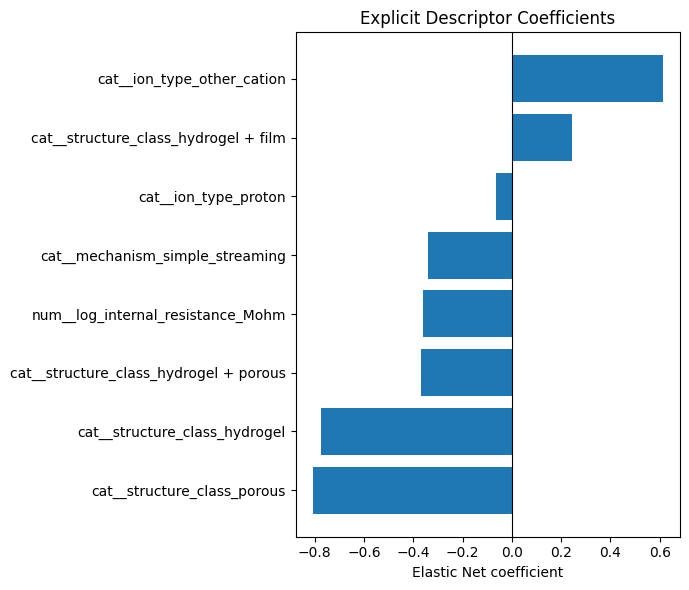

In [ ]:
top_n = 20

plot_df = nonzero_coef_df.head(top_n).sort_values("coefficient")

plt.figure(figsize=(7, 6))
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Elastic Net coefficient")
plt.title("Explicit Descriptor Coefficients")
plt.tight_layout()
plt.show()

## 09.8 Predicted vs observed plot

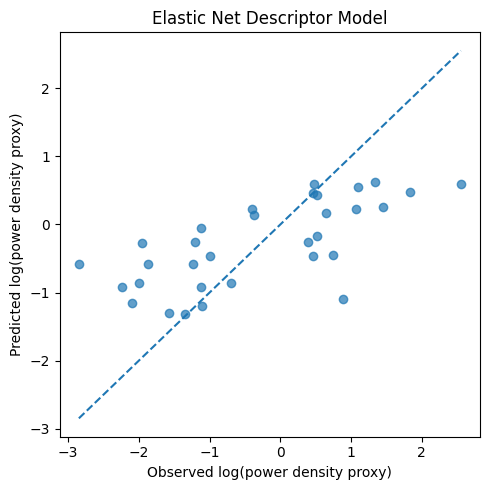

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_test, alpha=0.7)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed log(power density proxy)")
plt.ylabel("Predicted log(power density proxy)")
plt.title("Elastic Net Descriptor Model")
plt.tight_layout()
plt.show()

## 09.10 Polynomial-enhanced descriptor model

The first Elastic Net descriptor model provides a sparse linear design rule. However, hydrovoltaic performance may depend on coupled effects among internal resistance, structure, ionic environment, and mechanism labels.

Here, we construct a second-order polynomial descriptor model to test whether low-order interaction terms improve the descriptor representation while preserving interpretability.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num_poly",
            Pipeline(steps=[
                ("scaler", StandardScaler()),
                ("poly", PolynomialFeatures(
                    degree=2,
                    include_bias=False
                ))
            ]),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_features
        )
    ]
)

poly_elastic_net_cv = Pipeline(steps=[
    ("preprocess", poly_preprocessor),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-4, 2, 100),
        cv=5,
        max_iter=30000,
        random_state=42
    ))
])

In [ ]:
poly_elastic_net_cv.fit(X_train, y_train)

y_poly_train = poly_elastic_net_cv.predict(X_train)
y_poly_test = poly_elastic_net_cv.predict(X_test)

poly_train_r2 = r2_score(y_train, y_poly_train)
poly_test_r2 = r2_score(y_test, y_poly_test)

poly_test_mse = mean_squared_error(y_test, y_poly_test)
poly_test_rmse = np.sqrt(poly_test_mse)

poly_test_mae = mean_absolute_error(y_test, y_poly_test)

print("Polynomial descriptor model")
print("Train R2:", poly_train_r2)
print("Test R2:", poly_test_r2)
print("Test RMSE:", poly_test_rmse)
print("Test MAE:", poly_test_mae)

poly_model = poly_elastic_net_cv.named_steps["model"]

print("Best alpha:", poly_model.alpha_)
print("Best l1_ratio:", poly_model.l1_ratio_)

Polynomial descriptor model
Train R2: 0.33323483985456837
Test R2: 0.4369515042416182
Test RMSE: 1.009454617203444
Test MAE: 0.8234755522382602
Best alpha: 0.01
Best l1_ratio: 0.1


## 09.11 Cross-validation for polynomial descriptor

In [ ]:
poly_cv_r2 = cross_val_score(
    poly_elastic_net_cv,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("Polynomial CV R2 scores:", poly_cv_r2)
print("Mean Polynomial CV R2:", poly_cv_r2.mean())
print("Std Polynomial CV R2:", poly_cv_r2.std())

c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Polynomial CV R2 scores: [0.28620328 0.28242668 0.19876417 0.2921442  0.07356019]
Mean Polynomial CV R2: 0.22661970244604737
Std Polynomial CV R2: 0.0838584811136788


## 09.12 Extract polynomial descriptor coefficients

In [ ]:
poly_feature_names = poly_elastic_net_cv.named_steps["preprocess"].get_feature_names_out()

poly_coefs = poly_elastic_net_cv.named_steps["model"].coef_

poly_coef_df = pd.DataFrame({
    "feature": poly_feature_names,
    "coefficient": poly_coefs
})

poly_coef_df["abs_coefficient"] = poly_coef_df["coefficient"].abs()
poly_coef_df = poly_coef_df.sort_values("abs_coefficient", ascending=False)

poly_nonzero_coef_df = poly_coef_df[poly_coef_df["abs_coefficient"] > 1e-6].copy()

print("Number of non-zero polynomial descriptor terms:", len(poly_nonzero_coef_df))

poly_nonzero_coef_df.head(30)

Number of non-zero polynomial descriptor terms: 9


,feature,coefficient,abs_coefficient
5,cat__structure_class_porous,-0.805844,0.805844
2,cat__structure_class_hydrogel,-0.774786,0.774786
6,cat__ion_type_other_cation,0.606719,0.606719
4,cat__structure_class_hydrogel + porous,-0.386762,0.386762
0,num_poly__log_internal_resistance_Mohm,-0.380969,0.380969
8,cat__mechanism_simple_streaming,-0.334577,0.334577
3,cat__structure_class_hydrogel + film,0.236609,0.236609
7,cat__ion_type_proton,-0.065960,0.065960
1,num_poly__log_internal_resistance_Mohm^2,0.027382,0.027382


In [ ]:
poly_nonzero_coef_df.to_csv(
    "../results/09_polynomial_elastic_net_descriptor_coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved polynomial descriptor coefficients.")

Saved polynomial descriptor coefficients.


## 09.13 Plot polynomial coefficient importance

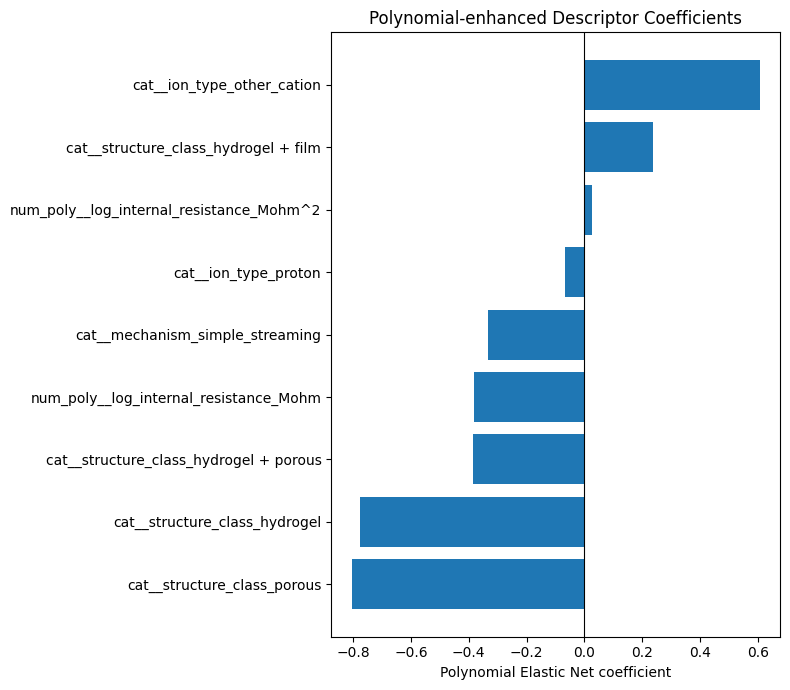

In [ ]:
top_n = 25

plot_poly_df = poly_nonzero_coef_df.head(top_n).sort_values("coefficient")

plt.figure(figsize=(8, 7))
plt.barh(plot_poly_df["feature"], plot_poly_df["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Polynomial Elastic Net coefficient")
plt.title("Polynomial-enhanced Descriptor Coefficients")
plt.tight_layout()
plt.show()

## 09.14 Predicted vs observed plot

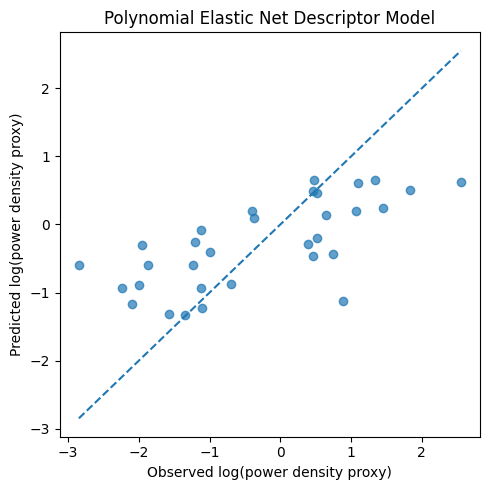

In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_poly_test, alpha=0.7)

min_val = min(y_test.min(), y_poly_test.min())
max_val = max(y_test.max(), y_poly_test.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed log(power density proxy)")
plt.ylabel("Predicted log(power density proxy)")
plt.title("Polynomial Elastic Net Descriptor Model")
plt.tight_layout()
plt.show()

## 09.15 Compare linear vs polynomial descriptor models

In [ ]:
descriptor_comparison = pd.DataFrame({
    "model": [
        "Linear Elastic Net descriptor",
        "Polynomial Elastic Net descriptor"
    ],
    "train_R2": [
        train_r2,
        poly_train_r2
    ],
    "test_R2": [
        test_r2,
        poly_test_r2
    ],
    "test_RMSE": [
        test_rmse,
        poly_test_rmse
    ],
    "test_MAE": [
        test_mae,
        poly_test_mae
    ],
    "cv_R2_mean": [
        cv_r2.mean(),
        poly_cv_r2.mean()
    ],
    "cv_R2_std": [
        cv_r2.std(),
        poly_cv_r2.std()
    ],
    "nonzero_terms": [
        len(nonzero_coef_df),
        len(poly_nonzero_coef_df)
    ]
})

descriptor_comparison

,model,train_R2,test_R2,test_RMSE,test_MAE,cv_R2_mean,cv_R2_std,nonzero_terms
0,Linear Elastic Net descriptor,0.331966,0.428578,1.016933,0.827393,0.251254,0.091204,8
1,Polynomial Elastic Net descriptor,0.333235,0.436952,1.009455,0.823476,0.226620,0.083858,9


In [ ]:
descriptor_comparison.to_csv(
    "../results/09_descriptor_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved descriptor model comparison.")

Saved descriptor model comparison.


### Explicit descriptor modeling of hydrovoltaic performance

To extract an interpretable design rule, an Elastic Net–based descriptor model was constructed using a minimal set of system-level and categorical features. The resulting model achieves a test R² of ~0.43 and a cross-validation R² of ~0.25, indicating that a compact linear descriptor can capture a substantial fraction of the variance in hydrovoltaic performance.

Coefficient analysis reveals that internal resistance (log R) and structural class are the dominant contributors, while mechanism labels exhibit comparatively weaker effects. Notably, the coefficient associated with log R is consistently negative, confirming that device performance decreases with increasing internal resistance, in agreement with transport-limited behavior.

To assess the role of higher-order interactions, a second-order polynomial descriptor model was constructed. However, the inclusion of quadratic and interaction terms does not lead to meaningful improvement in predictive performance and yields only a marginal increase in model complexity. The quadratic term of log R and interaction terms remain negligible or are eliminated by regularization.

These results demonstrate that hydrovoltaic performance can be effectively described by a low-dimensional, near-linear descriptor dominated by transport-related variables, without the need for complex nonlinear coupling terms.

The descriptor analysis indicates that hydrovoltaic systems exhibit an unexpectedly low degree of nonlinear coupling among descriptors. Despite the complex physicochemical processes involved, the performance can be approximated by a compact linear combination of internal resistance and structural variables. The lack of improvement from polynomial expansion suggests that higher-order interactions play a limited role in governing system behavior.

This finding contrasts with many machine learning studies in materials science, where nonlinear models are often required to achieve high predictive accuracy. In the present case, the dominance of a linear descriptor implies that the underlying physics is governed by a small number of additive transport-related effects, rather than intricate multi-variable interactions.

Such a low-dimensional representation provides a more physically interpretable framework and supports the use of simple design rules for guiding hydrovoltaic device optimization.